# Mo phong tinh toan Local Outlier Factor (LOF) bang tay

Notebook nay minh hoa toan bo cac buoc tinh LOF tren tap du lieu nho (15-20 diem), khong dung sklearn.

## 1. Tao du lieu gia lap (15-20 diem)

Sinh du lieu 2D nho voi vai diem di biet; luu vao DataFrame.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Tao 12 diem binh thuong quanh (0, 0)
cluster_main = np.random.normal(loc=0.0, scale=0.6, size=(12, 2))

# Tao 2 diem gan cum phu (gan (4, 4))
cluster_minor = np.random.normal(loc=4.0, scale=0.5, size=(2, 2))

# Tao 2 diem di biet
outliers = np.array([
    [7.5, -0.5],
    [-3.5, 6.5]
])

points = np.vstack([cluster_main, cluster_minor, outliers])
labels = [f"p{i:02d}" for i in range(len(points))]

df_points = pd.DataFrame(points, columns=["x", "y"])
df_points.insert(0, "id", labels)

display(df_points)
print(f"So diem: {len(df_points)}")

,id,x,y
0,p00,0.298028,-0.082959
1,p01,0.388613,0.913818
2,p02,-0.140492,-0.140482
3,p03,0.947528,0.460461
4,p04,-0.281685,0.325536
5,p05,-0.278051,-0.279438
6,p06,0.145177,-1.147968
7,p07,-1.034951,-0.337373
8,p08,-0.607699,0.188548
9,p09,-0.544814,-0.847382


So diem: 16


## 2. Chuan hoa du lieu (tuy chon)

Ap dung chuan hoa thu cong (z-score hoac min-max) de so sanh anh huong khoang cach.

In [2]:
def min_max_scale(arr: np.ndarray) -> np.ndarray:
    min_val = arr.min(axis=0)
    max_val = arr.max(axis=0)
    return (arr - min_val) / (max_val - min_val)


def z_score_scale(arr: np.ndarray) -> np.ndarray:
    mean_val = arr.mean(axis=0)
    std_val = arr.std(axis=0, ddof=0)
    return (arr - mean_val) / std_val

X_raw = df_points[["x", "y"]].to_numpy()
X_minmax = min_max_scale(X_raw)
X_zscore = z_score_scale(X_raw)

# Chon bo du lieu de tinh LOF (doi de so sanh)
X = X_zscore

print("Vi du 5 diem dau tien (raw / min-max / z-score):")
for i in range(5):
    print(
        df_points.loc[i, "id"],
        X_raw[i].round(3),
        X_minmax[i].round(3),
        X_zscore[i].round(3)
    )

Vi du 5 diem dau tien (raw / min-max / z-score):
p00 [ 0.298 -0.083] [0.345 0.139] [-0.163 -0.404]
p01 [0.389 0.914] [0.354 0.27 ] [-0.125  0.069]
p02 [-0.14 -0.14] [0.305 0.132] [-0.347 -0.431]
p03 [0.948 0.46 ] [0.404 0.21 ] [ 0.11  -0.146]
p04 [-0.282  0.326] [0.293 0.193] [-0.407 -0.21 ]


## 3. Tinh khoang cach Euclid va k-distance

Tinh ma tran khoang cach; voi moi diem, lay k-distance va danh sach khoang cach tang dan.

In [3]:
k = 3
n = X.shape[0]

# Ma tran khoang cach Euclid
D = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            D[i, j] = 0.0
        else:
            D[i, j] = np.linalg.norm(X[i] - X[j])

# Sap xep khoang cach (bo qua chinh no)
sorted_distances = []
k_distance = np.zeros(n)
for i in range(n):
    dists = [(j, D[i, j]) for j in range(n) if j != i]
    dists_sorted = sorted(dists, key=lambda x: x[1])
    sorted_distances.append(dists_sorted)
    k_distance[i] = dists_sorted[k - 1][1]

print("k-distance cho tung diem:")
for i in range(n):
    print(df_points.loc[i, "id"], "->", round(k_distance[i], 4))

k-distance cho tung diem:
p00 -> 0.2596
p01 -> 0.474
p02 -> 0.2287
p03 -> 0.3755
p04 -> 0.2868
p05 -> 0.2616
p06 -> 0.4485
p07 -> 0.3195
p08 -> 0.2616
p09 -> 0.3177
p10 -> 0.4289
p11 -> 0.3039
p12 -> 2.0666
p13 -> 2.051
p14 -> 2.7931
p15 -> 3.2245


## 4. Xac dinh k-nearest neighbors

Lay tap k lang gieng gan nhat cho tung diem; xu ly truong hop dong khoang cach.

In [4]:
neighbors = []
for i in range(n):
    kth = k_distance[i]
    neigh = [j for j in range(n) if j != i and D[i, j] <= kth]
    neighbors.append(neigh)

print("So lang gieng (bao gom truong hop dong khoang cach):")
for i in range(n):
    print(df_points.loc[i, "id"], "->", len(neighbors[i]), [df_points.loc[j, "id"] for j in neighbors[i]])

So lang gieng (bao gom truong hop dong khoang cach):
p00 -> 3 ['p02', 'p05', 'p10']
p01 -> 3 ['p00', 'p03', 'p04']
p02 -> 3 ['p00', 'p04', 'p05']
p03 -> 3 ['p00', 'p01', 'p10']
p04 -> 3 ['p02', 'p05', 'p08']
p05 -> 3 ['p00', 'p02', 'p08']
p06 -> 3 ['p05', 'p09', 'p11']
p07 -> 3 ['p05', 'p08', 'p09']
p08 -> 3 ['p02', 'p04', 'p05']
p09 -> 3 ['p05', 'p07', 'p11']
p10 -> 3 ['p00', 'p02', 'p03']
p11 -> 3 ['p05', 'p06', 'p09']
p12 -> 3 ['p01', 'p03', 'p13']
p13 -> 3 ['p01', 'p03', 'p12']
p14 -> 3 ['p03', 'p10', 'p12']
p15 -> 3 ['p01', 'p04', 'p13']


## 5. Tinh reachability distance va local reachability density (LRD)

Tinh reachability distance theo cong thuc $\text{reach-dist}_k(p,o)=\max\{k\text{-dist}(o),\,d(p,o)\}$, sau do LRD cho tung diem.

In [5]:
reach_dist = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            reach_dist[i, j] = 0.0
        else:
            reach_dist[i, j] = max(k_distance[j], D[i, j])

lrd = np.zeros(n)
for i in range(n):
    neigh = neighbors[i]
    if not neigh:
        lrd[i] = 0.0
        continue
    avg_reach = np.mean([reach_dist[i, j] for j in neigh])
    lrd[i] = 1.0 / avg_reach if avg_reach > 0 else 0.0

print("LRD cho tung diem:")
for i in range(n):
    print(df_points.loc[i, "id"], "->", round(lrd[i], 4))

LRD cho tung diem:
p00 -> 3.2635
p01 -> 2.4077
p02 -> 3.7133
p03 -> 2.3467
p04 -> 3.8606
p05 -> 4.0006
p06 -> 2.7889
p07 -> 3.1763
p08 -> 3.7537
p09 -> 3.2786
p10 -> 2.8197
p11 -> 2.8035
p12 -> 0.4867
p13 -> 0.4896
p14 -> 0.3631
p15 -> 0.3175


## 6. Tinh chi so LOF va gan nhan outlier

Tinh LOF cho tung diem va gan nhan dua tren nguong (vi du LOF > 1.5).

In [6]:
lof = np.zeros(n)
for i in range(n):
    neigh = neighbors[i]
    if not neigh or lrd[i] == 0:
        lof[i] = 0.0
        continue
    lof[i] = np.mean([lrd[j] for j in neigh]) / lrd[i]

threshold = 1.5
is_outlier = lof > threshold

result = df_points.copy()
result["k_dist"] = k_distance
result["lrd"] = lrd
result["lof"] = lof
result["outlier"] = is_outlier

result_sorted = result.sort_values("lof", ascending=False)
display(result_sorted)
print("So outlier theo nguong:", int(is_outlier.sum()))

,id,x,y,k_dist,lrd,lof,outlier
15,p15,-3.500000,6.500000,3.224547,0.317515,7.094595,True
14,p14,7.500000,-0.500000,2.793111,0.363093,5.189678,True
12,p12,3.727809,4.055461,2.066645,0.486651,3.591928,True
13,p13,3.424503,4.187849,2.051044,0.489610,3.568198,True
1,p01,0.388613,0.913818,0.474009,2.407743,1.311151,False
3,p03,0.947528,0.460461,0.375452,2.346688,1.206085,False
6,p06,0.145177,-1.147968,0.448518,2.788947,1.205071,False
11,p11,0.040517,-0.854849,0.303877,2.803489,1.197092,False
7,p07,-1.034951,-0.337373,0.319510,3.176253,1.157845,False
10,p10,0.879389,-0.135466,0.428936,2.819676,1.102188,False


So outlier theo nguong: 4


## 7. Truc quan hoa diem va LOF

Ve scatter plot, to mau theo LOF hoac nhan outlier de minh hoa ket qua.

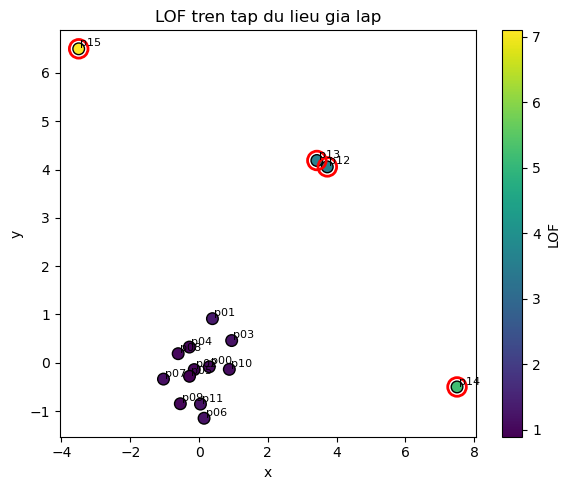

In [7]:
plt.figure(figsize=(6, 5))
sc = plt.scatter(result["x"], result["y"], c=result["lof"], cmap="viridis", s=70, edgecolor="k")

# Danh dau outlier
outlier_points = result[result["outlier"]]
plt.scatter(outlier_points["x"], outlier_points["y"], facecolors="none", edgecolors="red", s=180, linewidths=2)

for _, row in result.iterrows():
    plt.text(row["x"] + 0.05, row["y"] + 0.05, row["id"], fontsize=8)

plt.colorbar(sc, label="LOF")
plt.title("LOF tren tap du lieu gia lap")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()